<a href="https://colab.research.google.com/github/mr-zero-000/Statistical-Learning-e23034/blob/main/Assignment%207/2D_Part_B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Running single illustrative trajectory (with injected GPS outliers)...


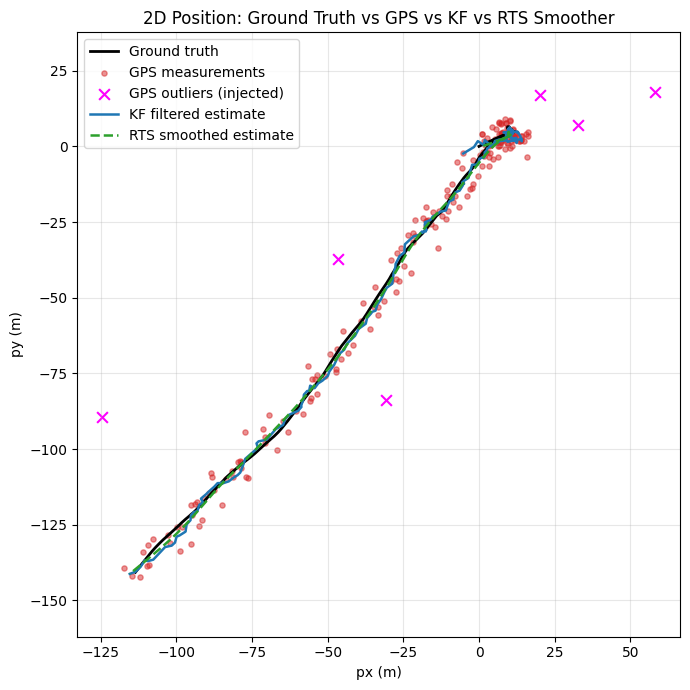

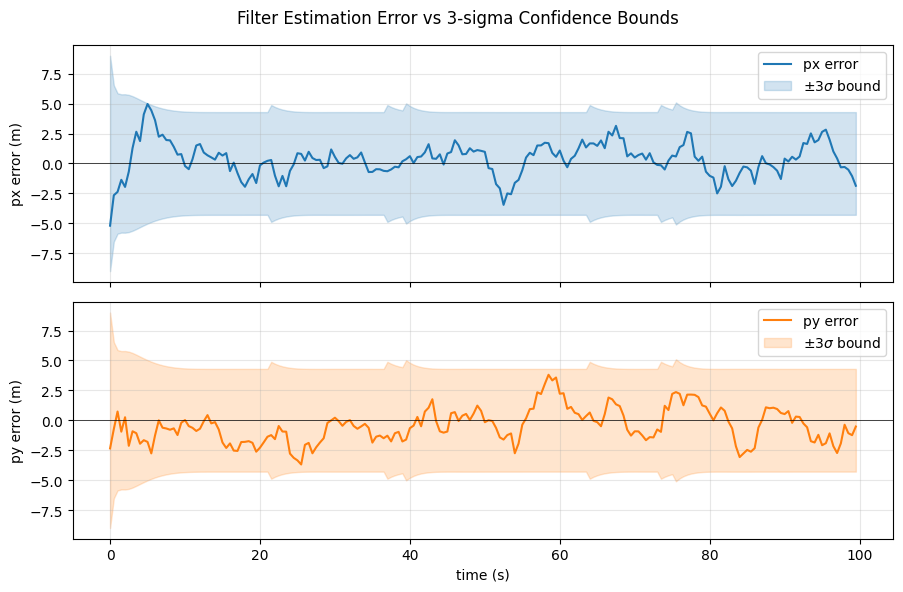

  Raw GPS position RMSE:        8.355 m
  KF filtered position RMSE:    2.076 m
  RTS smoothed position RMSE:   1.314 m
  Outliers injected at indices: [np.int64(43), np.int64(74), np.int64(79), np.int64(128), np.int64(147), np.int64(151)]

Running Monte Carlo consistency study (no outliers, gate off)...


/tmp/ipykernel_3329/2621981698.py:243: RuntimeWarning: Mean of empty slice
  avg_nis = np.nanmean(nis_runs, axis=0)


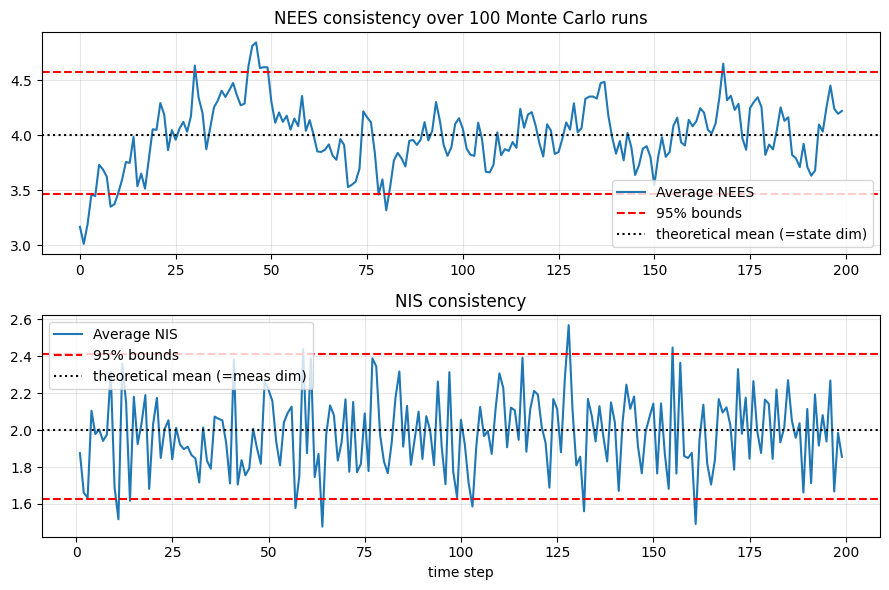

  Average NEES (should be ~4, within bounds 3.46-4.57): 4.001
  Average NIS  (should be ~2, within bounds 1.63-2.41): 1.981


In [1]:
"""
2D Constant-Velocity Kalman Filter for Noisy GPS Position Tracking
====================================================================

State:        x = [px, py, vx, vy]^T
Measurement:  y = [px_meas, py_meas]^T   (GPS gives position only)

Model:
    x_k^- = A x_{k-1}^+ + G w_{k-1},     w ~ N(0, Sigma_p)   (process noise)
    y_k   = H x_k^+ + z_k,               z ~ N(0, Sigma_m)   (measurement noise)

This script implements:
    1. KalmanFilter2D      - standard discrete-time KF (predict/update)
    2. rts_smoother         - Rauch-Tung-Striebel fixed-interval smoother
    3. Chi-square innovation gating to reject GPS outliers (multipath/jumps)
    4. A synthetic trajectory generator + noisy GPS measurement generator
    5. Monte Carlo NEES/NIS consistency checks (the standard way to verify
       a Kalman filter is correctly tuned, not just "runs without crashing")
    6. Plots: trajectory, per-axis error with 3-sigma bounds, NEES/NIS plots
"""

from __future__ import annotations
import numpy as np
from dataclasses import dataclass, field
from scipy.stats import chi2
import matplotlib.pyplot as plt

rng_global = np.random.default_rng(42)


# ----------------------------------------------------------------------
# 1. Model matrices (derived in Part A)
# ----------------------------------------------------------------------
def build_model(dt: float, sigma_p: float, sigma_m: float):
    """Return A, G, H, Sigma_p, Sigma_m for the CV model at sample time dt.

    sigma_p : std dev of the random acceleration driving the process noise (m/s^2)
    sigma_m : std dev of the GPS position measurement noise (m), assumed isotropic
    """
    A = np.array([
        [1, 0, dt, 0],
        [0, 1, 0, dt],
        [0, 0, 1, 0],
        [0, 0, 0, 1],
    ])

    G = np.array([
        [0.5 * dt**2, 0],
        [0,           0.5 * dt**2],
        [dt,          0],
        [0,           dt],
    ])

    H = np.array([
        [1, 0, 0, 0],
        [0, 1, 0, 0],
    ])

    Sigma_p = (sigma_p ** 2) * np.eye(2)     # 2x2 acceleration-noise covariance
    Sigma_m = (sigma_m ** 2) * np.eye(2)     # 2x2 GPS measurement covariance

    return A, G, H, Sigma_p, Sigma_m


# ----------------------------------------------------------------------
# 2. Kalman filter
# ----------------------------------------------------------------------
@dataclass
class KalmanFilter2D:
    A: np.ndarray
    G: np.ndarray
    H: np.ndarray
    Sigma_p: np.ndarray
    Sigma_m: np.ndarray
    x: np.ndarray              # current state estimate (posterior), shape (4,)
    P: np.ndarray              # current state covariance (posterior), shape (4,4)
    gate_chi2: float = None    # 95% chi-square gate threshold (2 dof) if set

    history: dict = field(default_factory=lambda: {
        "x_pred": [], "P_pred": [], "x_filt": [], "P_filt": [],
        "innov": [], "S": [], "rejected": []
    })

    @property
    def Q(self):
        return self.G @ self.Sigma_p @ self.G.T

    def predict(self):
        self.x = self.A @ self.x
        self.P = self.A @ self.P @ self.A.T + self.Q
        self.history["x_pred"].append(self.x.copy())
        self.history["P_pred"].append(self.P.copy())
        return self.x, self.P

    def update(self, y: np.ndarray):
        innov = y - self.H @ self.x                      # innovation
        S = self.H @ self.P @ self.H.T + self.Sigma_m     # innovation covariance
        d2 = innov @ np.linalg.solve(S, innov)            # Mahalanobis^2 (NIS)

        rejected = False
        if self.gate_chi2 is not None and d2 > self.gate_chi2:
            # Outlier: skip the update, keep the prediction as posterior
            rejected = True
            self.history["innov"].append(innov.copy())
            self.history["S"].append(S.copy())
            self.history["rejected"].append(True)
            self.history["x_filt"].append(self.x.copy())
            self.history["P_filt"].append(self.P.copy())
            return self.x, self.P, d2, rejected

        K = self.P @ self.H.T @ np.linalg.inv(S)          # Kalman gain
        self.x = self.x + K @ innov
        I = np.eye(self.P.shape[0])
        # Joseph form for numerical stability / guaranteed symmetric PSD result
        self.P = (I - K @ self.H) @ self.P @ (I - K @ self.H).T + K @ self.Sigma_m @ K.T

        self.history["innov"].append(innov.copy())
        self.history["S"].append(S.copy())
        self.history["rejected"].append(False)
        self.history["x_filt"].append(self.x.copy())
        self.history["P_filt"].append(self.P.copy())
        return self.x, self.P, d2, rejected

    def step(self, y: np.ndarray):
        self.predict()
        return self.update(y)


# ----------------------------------------------------------------------
# 3. RTS (Rauch-Tung-Striebel) fixed-interval smoother
# ----------------------------------------------------------------------
def rts_smoother(A, x_filt, P_filt, x_pred, P_pred):
    """Backward pass producing smoothed estimates x_s[k], P_s[k] using all
    measurements in the batch (offline post-processing)."""
    N = len(x_filt)
    x_s = [None] * N
    P_s = [None] * N
    x_s[-1], P_s[-1] = x_filt[-1], P_filt[-1]

    for k in range(N - 2, -1, -1):
        Ck = P_filt[k] @ A.T @ np.linalg.inv(P_pred[k + 1])
        x_s[k] = x_filt[k] + Ck @ (x_s[k + 1] - x_pred[k + 1])
        P_s[k] = P_filt[k] + Ck @ (P_s[k + 1] - P_pred[k + 1]) @ Ck.T

    return np.array(x_s), np.array(P_s)


# ----------------------------------------------------------------------
# 4. Synthetic trajectory + noisy GPS generator
# ----------------------------------------------------------------------
def simulate_truth(N, dt, sigma_p_true, x0, rng, n_outliers=0, outlier_scale=15.0):
    """Generate ground truth via the CV model driven by true process noise,
    and noisy GPS measurements. Optionally inject GPS outliers (e.g. multipath)."""
    A, G, H, _, _ = build_model(dt, sigma_p_true, sigma_m=1.0)  # sigma_m placeholder
    x_true = np.zeros((N, 4))
    x_true[0] = x0
    for k in range(1, N):
        w = rng.normal(0, sigma_p_true, size=2)
        x_true[k] = A @ x_true[k - 1] + G @ w
    return x_true


def simulate_measurements(x_true, H, sigma_m, rng, n_outliers=0, outlier_scale=15.0):
    N = x_true.shape[0]
    Sigma_m = (sigma_m ** 2) * np.eye(2)
    y = (H @ x_true.T).T + rng.multivariate_normal(np.zeros(2), Sigma_m, size=N)
    outlier_idx = rng.choice(N, size=n_outliers, replace=False) if n_outliers else []
    for idx in outlier_idx:
        y[idx] += rng.normal(0, outlier_scale * sigma_m, size=2)
    return y, set(outlier_idx)


# ----------------------------------------------------------------------
# 5. Single run: filter + smooth a trajectory, return everything
# ----------------------------------------------------------------------
def run_filter(N=200, dt=0.5, sigma_p_true=0.4, sigma_p_filter=0.4, sigma_m=3.0,
               n_outliers=5, use_gate=True, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    x0 = np.array([0.0, 0.0, 2.0, 1.0])
    x_true = simulate_truth(N, dt, sigma_p_true, x0, rng)

    A, G, H, Sigma_p, Sigma_m = build_model(dt, sigma_p_filter, sigma_m)
    y_meas, outlier_idx = simulate_measurements(x_true, H, sigma_m, rng, n_outliers)

    # Initialize filter with a loose prior around the first measurement
    x0_filt = np.array([y_meas[0, 0], y_meas[0, 1], 0.0, 0.0])
    P0 = np.diag([sigma_m**2, sigma_m**2, 4.0, 4.0])

    gate = chi2.ppf(0.997, df=2) if use_gate else None  # 99.7% confidence gate
    kf = KalmanFilter2D(A=A, G=G, H=H, Sigma_p=Sigma_p, Sigma_m=Sigma_m,
                         x=x0_filt.copy(), P=P0.copy(), gate_chi2=gate)

    nees_list, nis_list = [], []
    for k in range(N):
        if k == 0:
            # treat first sample as already "filtered" (no predict before first meas)
            kf.history["x_pred"].append(kf.x.copy())
            kf.history["P_pred"].append(kf.P.copy())
            kf.history["x_filt"].append(kf.x.copy())
            kf.history["P_filt"].append(kf.P.copy())
            kf.history["innov"].append(np.zeros(2))
            kf.history["S"].append(np.eye(2))
            kf.history["rejected"].append(False)
            nis_list.append(np.nan)
        else:
            _, _, d2, rejected = kf.step(y_meas[k])
            nis_list.append(d2 if not rejected else np.nan)

        err = x_true[k] - kf.x
        nees = err @ np.linalg.solve(kf.P, err)
        nees_list.append(nees)

    x_filt = np.array(kf.history["x_filt"])
    P_filt = kf.history["P_filt"]
    x_pred = np.array(kf.history["x_pred"])
    P_pred = kf.history["P_pred"]

    x_smooth, P_smooth = rts_smoother(A, list(x_filt), P_filt, list(x_pred), P_pred)

    return dict(x_true=x_true, y_meas=y_meas, x_filt=x_filt, P_filt=P_filt,
                x_smooth=x_smooth, P_smooth=P_smooth, nees=np.array(nees_list),
                nis=np.array(nis_list), outlier_idx=outlier_idx, dt=dt)


# ----------------------------------------------------------------------
# 6. Monte Carlo consistency study (NEES / NIS averaged over runs)
# ----------------------------------------------------------------------
def monte_carlo_consistency(n_runs=100, N=200, dt=0.5, sigma_p_true=0.4,
                             sigma_p_filter=0.4, sigma_m=3.0):
    nees_runs = np.zeros((n_runs, N))
    nis_runs = np.zeros((n_runs, N))
    for r in range(n_runs):
        rng = np.random.default_rng(1000 + r)
        res = run_filter(N=N, dt=dt, sigma_p_true=sigma_p_true,
                          sigma_p_filter=sigma_p_filter, sigma_m=sigma_m,
                          n_outliers=0, use_gate=False, rng=rng)
        nees_runs[r] = res["nees"]
        nis_runs[r] = res["nis"]

    avg_nees = nees_runs.mean(axis=0)
    avg_nis = np.nanmean(nis_runs, axis=0)

    # 95% two-sided chi-square bounds for the AVERAGE over n_runs (state dim=4, meas dim=2)
    dof_state, dof_meas = 4, 2
    nees_lo = chi2.ppf(0.025, df=n_runs * dof_state) / n_runs
    nees_hi = chi2.ppf(0.975, df=n_runs * dof_state) / n_runs
    nis_lo = chi2.ppf(0.025, df=n_runs * dof_meas) / n_runs
    nis_hi = chi2.ppf(0.975, df=n_runs * dof_meas) / n_runs

    return dict(avg_nees=avg_nees, avg_nis=avg_nis,
                nees_bounds=(nees_lo, nees_hi), nis_bounds=(nis_lo, nis_hi))


# ----------------------------------------------------------------------
# 7. Plots
# ----------------------------------------------------------------------
def plot_results(res):
    x_true, y_meas = res["x_true"], res["y_meas"]
    x_filt, x_smooth = res["x_filt"], res["x_smooth"]
    outlier_idx = res["outlier_idx"]
    N = x_true.shape[0]
    t = np.arange(N) * res["dt"]

    # --- Trajectory plot ---
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.plot(x_true[:, 0], x_true[:, 1], 'k-', lw=2, label="Ground truth")
    good = [i for i in range(N) if i not in outlier_idx]
    bad = sorted(outlier_idx)
    ax.scatter(y_meas[good, 0], y_meas[good, 1], s=14, c='tab:red', alpha=0.5, label="GPS measurements")
    if bad:
        ax.scatter(y_meas[bad, 0], y_meas[bad, 1], s=60, marker='x', c='magenta', label="GPS outliers (injected)")
    ax.plot(x_filt[:, 0], x_filt[:, 1], 'tab:blue', lw=1.8, label="KF filtered estimate")
    ax.plot(x_smooth[:, 0], x_smooth[:, 1], 'tab:green', lw=1.8, ls='--', label="RTS smoothed estimate")
    ax.set_xlabel("px (m)"); ax.set_ylabel("py (m)")
    ax.set_title("2D Position: Ground Truth vs GPS vs KF vs RTS Smoother")
    ax.legend(); ax.axis('equal'); ax.grid(alpha=0.3)
    fig.tight_layout(); plt.show()

    # --- Per-axis error with 3-sigma bounds ---
    P_filt = np.array(res["P_filt"])
    err_x = x_filt[:, 0] - x_true[:, 0]
    err_y = x_filt[:, 1] - x_true[:, 1]
    std_x = np.sqrt(P_filt[:, 0, 0])
    std_y = np.sqrt(P_filt[:, 1, 1])

    fig, axs = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
    axs[0].plot(t, err_x, 'tab:blue', label="px error")
    axs[0].fill_between(t, -3*std_x, 3*std_x, color='tab:blue', alpha=0.2, label=r"$\pm3\sigma$ bound")
    axs[0].axhline(0, color='k', lw=0.5)
    axs[0].set_ylabel("px error (m)"); axs[0].legend(); axs[0].grid(alpha=0.3)

    axs[1].plot(t, err_y, 'tab:orange', label="py error")
    axs[1].fill_between(t, -3*std_y, 3*std_y, color='tab:orange', alpha=0.2, label=r"$\pm3\sigma$ bound")
    axs[1].axhline(0, color='k', lw=0.5)
    axs[1].set_ylabel("py error (m)"); axs[1].set_xlabel("time (s)")
    axs[1].legend(); axs[1].grid(alpha=0.3)
    fig.suptitle("Filter Estimation Error vs 3-sigma Confidence Bounds")
    fig.tight_layout(); plt.show()


def plot_consistency(mc, n_runs):
    N = len(mc["avg_nees"])
    t = np.arange(N)

    fig, axs = plt.subplots(2, 1, figsize=(9, 6))
    axs[0].plot(t, mc["avg_nees"], label="Average NEES")
    axs[0].axhline(mc["nees_bounds"][0], color='r', ls='--', label="95% bounds")
    axs[0].axhline(mc["nees_bounds"][1], color='r', ls='--')
    axs[0].axhline(4, color='k', ls=':', label="theoretical mean (=state dim)")
    axs[0].set_title(f"NEES consistency over {n_runs} Monte Carlo runs")
    axs[0].legend(); axs[0].grid(alpha=0.3)

    axs[1].plot(t, mc["avg_nis"], label="Average NIS")
    axs[1].axhline(mc["nis_bounds"][0], color='r', ls='--', label="95% bounds")
    axs[1].axhline(mc["nis_bounds"][1], color='r', ls='--')
    axs[1].axhline(2, color='k', ls=':', label="theoretical mean (=meas dim)")
    axs[1].set_title("NIS consistency")
    axs[1].set_xlabel("time step"); axs[1].legend(); axs[1].grid(alpha=0.3)

    fig.tight_layout(); plt.show()


# ----------------------------------------------------------------------
# 8. Main
# ----------------------------------------------------------------------
if __name__ == "__main__":
    print("Running single illustrative trajectory (with injected GPS outliers)...")
    res = run_filter(N=200, dt=0.5, sigma_p_true=0.4, sigma_p_filter=0.4,
                      sigma_m=3.0, n_outliers=6, use_gate=True,
                      rng=np.random.default_rng(7))
    plot_results(res)

    rmse_filt = np.sqrt(np.mean(np.sum((res["x_filt"][:, :2] - res["x_true"][:, :2])**2, axis=1)))
    rmse_smooth = np.sqrt(np.mean(np.sum((res["x_smooth"][:, :2] - res["x_true"][:, :2])**2, axis=1)))
    rmse_meas = np.sqrt(np.mean(np.sum((res["y_meas"] - res["x_true"][:, :2])**2, axis=1)))
    print(f"  Raw GPS position RMSE:        {rmse_meas:.3f} m")
    print(f"  KF filtered position RMSE:    {rmse_filt:.3f} m")
    print(f"  RTS smoothed position RMSE:   {rmse_smooth:.3f} m")
    print(f"  Outliers injected at indices: {sorted(res['outlier_idx'])}")

    print("\nRunning Monte Carlo consistency study (no outliers, gate off)...")
    n_runs = 100
    mc = monte_carlo_consistency(n_runs=n_runs, N=200, dt=0.5,
                                  sigma_p_true=0.4, sigma_p_filter=0.4, sigma_m=3.0)
    plot_consistency(mc, n_runs)
    print(f"  Average NEES (should be ~4, within bounds "
          f"{mc['nees_bounds'][0]:.2f}-{mc['nees_bounds'][1]:.2f}): "
          f"{mc['avg_nees'].mean():.3f}")
    print(f"  Average NIS  (should be ~2, within bounds "
          f"{mc['nis_bounds'][0]:.2f}-{mc['nis_bounds'][1]:.2f}): "
          f"{np.nanmean(mc['avg_nis']):.3f}")